# Dataset Forensics

Inspect the workbook structure, data quality, target variable, and potential leakage.

In [1]:
import sys
print(sys.executable)

c:\Projects\0xPOWER\cpri-hackathon\venv\Scripts\python.exe


In [2]:
!python -m pip install --upgrade pip
!pip install pandas numpy openpyxl matplotlib seaborn scikit-learn ipykernel

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

FILE_PATH = "../data/raw/CPRI_Hackathon_Screening_Dataset_PARTICIPANT.xlsx"

train = pd.read_excel(FILE_PATH, sheet_name="Training_Data")
test = pd.read_excel(FILE_PATH, sheet_name="Test_Data")
submission = pd.read_excel(FILE_PATH, sheet_name="Sample_Submission")

In [4]:
print("Training shape:", train.shape)
print("Test shape:", test.shape)
print("Submission shape:", submission.shape)

display(train.head())

Training shape: (1000, 11)
Test shape: (350, 9)
Submission shape: (350, 3)


,Test_ID,Applied_Voltage_kV,Load_Current_A,Ambient_Temperature_C,Test_Duration_min,Sensor_S1,Sensor_S2,Sensor_S3,Sensor_S4,Reference_Parameter,Validity_Label
0,TRN-0889,16.7196,93.1228,33.3421,19.9546,13.6343,15.1361,16.5062,62.9115,34.8501,Valid
1,TRN-0820,21.4477,82.5230,34.4915,47.0553,15.6466,15.9849,19.3289,39.8667,30.4762,Valid
2,TRN-0411,19.2432,107.3619,29.4673,5.2763,15.1080,16.6481,18.3834,44.5390,46.8046,Valid
3,TRN-0754,22.7191,69.9690,26.9695,20.3051,14.9296,14.7026,18.6269,44.2673,23.7153,Valid
4,TRN-0707,13.5008,108.8999,35.5415,29.1939,12.6845,15.2455,14.6132,44.0720,48.5994,Valid


In [5]:
print(train["Validity_Label"].value_counts())

print(train["Validity_Label"].value_counts(normalize=True))

train["Reference_Parameter"].describe()

Validity_Label
Valid      866
Invalid    134
Name: count, dtype: int64
Validity_Label
Valid      0.866
Invalid    0.134
Name: proportion, dtype: float64


count    1000.000000
mean       26.692486
std        10.694772
min        11.918300
25%        18.415550
50%        23.018250
75%        33.443650
max        61.584800
Name: Reference_Parameter, dtype: float64

*Dataset Identity*

In [6]:
print("TRAINING DATA")
print("-" * 50)

print("Rows:", train.shape[0])
print("Columns:", train.shape[1])

print("\nColumns:")
for col in train.columns:
    print(f" - {col}")

TRAINING DATA
--------------------------------------------------
Rows: 1000
Columns: 11

Columns:
 - Test_ID
 - Applied_Voltage_kV
 - Load_Current_A
 - Ambient_Temperature_C
 - Test_Duration_min
 - Sensor_S1
 - Sensor_S2
 - Sensor_S3
 - Sensor_S4
 - Reference_Parameter
 - Validity_Label


In [7]:
#Target variables
train_only_columns = set(train.columns) - set(test.columns)
test_only_columns = set(test.columns) - set(train.columns)

print("Only in training:", train_only_columns)
print("Only in test:", test_only_columns)

Only in training: {'Reference_Parameter', 'Validity_Label'}
Only in test: set()


**Dataset Identity**: The training dataset contains 1,000 observations and 11 columns, while the test dataset contains 350 observations and 9 columns. The additional training columns are the two prediction targets: **Reference_Parameter** and **Validity_Label**.

In [8]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Test_ID                1000 non-null   str    
 1   Applied_Voltage_kV     1000 non-null   float64
 2   Load_Current_A         1000 non-null   float64
 3   Ambient_Temperature_C  1000 non-null   float64
 4   Test_Duration_min      1000 non-null   float64
 5   Sensor_S1              994 non-null    float64
 6   Sensor_S2              998 non-null    float64
 7   Sensor_S3              993 non-null    float64
 8   Sensor_S4              971 non-null    float64
 9   Reference_Parameter    1000 non-null   float64
 10  Validity_Label         1000 non-null   str    
dtypes: float64(9), str(2)
memory usage: 86.1 KB


In [9]:
dtype_summary = pd.DataFrame({
    "dtype": train.dtypes,
    "non_null": train.notna().sum(),
    "null": train.isna().sum(),
    "unique": train.nunique()
})

display(dtype_summary)

,dtype,non_null,null,unique
Test_ID,str,1000,0,1000
Applied_Voltage_kV,float64,1000,0,988
Load_Current_A,float64,1000,0,988
Ambient_Temperature_C,float64,1000,0,967
Test_Duration_min,float64,1000,0,985
Sensor_S1,float64,994,6,975
Sensor_S2,float64,998,2,982
Sensor_S3,float64,993,7,974
Sensor_S4,float64,971,29,958
Reference_Parameter,float64,1000,0,999


In [10]:
display(train.describe().T)

,count,mean,std,min,25%,50%,75%,max
Applied_Voltage_kV,1000.0,20.135588,7.125442,8.0142,14.011275,19.98500,26.722750,31.9783
Load_Current_A,1000.0,63.272139,27.886854,15.0079,39.316450,63.71130,87.649725,109.9526
Ambient_Temperature_C,1000.0,34.180393,7.517560,18.0000,28.841600,34.58915,39.081650,55.0000
Test_Duration_min,1000.0,31.990863,15.798383,5.0434,18.493000,31.83625,45.340800,59.9745
Sensor_S1,994.0,13.503143,4.084500,0.0000,10.470925,13.62775,16.508225,28.5205
Sensor_S2,998.0,13.663169,3.926916,-0.2015,10.867375,13.57855,16.341875,28.0601
Sensor_S3,993.0,16.967140,5.154167,0.0000,12.851000,16.92690,21.360800,35.7555
Sensor_S4,971.0,49.756865,12.533116,11.4004,41.777550,49.45430,57.658850,87.7375
Reference_Parameter,1000.0,26.692486,10.694772,11.9183,18.415550,23.01825,33.443650,61.5848


In [11]:
#Missing Values 
missing = train.isnull().sum()

missing = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": (missing / len(train)) * 100
})

missing = missing[missing["missing_count"] > 0]
missing = missing.sort_values("missing_count", ascending=False)

display(missing)

,missing_count,missing_percent
Sensor_S4,29,2.9
Sensor_S3,7,0.7
Sensor_S1,6,0.6
Sensor_S2,2,0.2


In [12]:
test_missing = pd.DataFrame({
    "missing_count": test.isnull().sum(),
    "missing_percent": test.isnull().mean() * 100
})

display(
    test_missing[test_missing["missing_count"] > 0]
    .sort_values("missing_count", ascending=False)
)

,missing_count,missing_percent
Sensor_S4,11,3.142857
Sensor_S2,3,0.857143
Sensor_S3,2,0.571429
Sensor_S1,1,0.285714


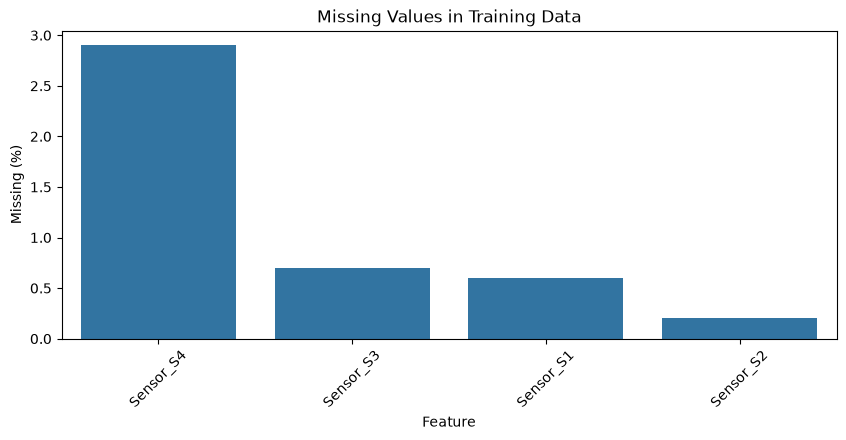

In [13]:
plt.figure(figsize=(10, 4))

sns.barplot(
    x=missing.index,
    y=missing["missing_percent"]
)

plt.title("Missing Values in Training Data")
plt.ylabel("Missing (%)")
plt.xlabel("Feature")
plt.xticks(rotation=45)
plt.show()

**Missing Values**: Missing observations are concentrated in the sensor variables, with Sensor_S4 showing noticeably more missing observations than the other sensors. No imputation was performed during the forensic stage because missing sensor readings may themselves reflect measurement or sensor behavior.

Possibilities:

1) S4 is genuinely optional.
2) S4 is an auxiliary sensor.
3) Missing S4 is expected under some valid condition

***Study:*** *Missingness in S1–S3 is a strong candidate validity signal, while missing S4 appears associated with valid records in the training set. This needs to be validated through the underlying measurement patterns and cross-validation.*

In [14]:
# Duplicate Rows
print("Exact duplicate rows:", train.duplicated().sum())

print("Unique Test_IDs:", train["Test_ID"].nunique())
print("Total rows:", len(train))
print("Duplicate Test_IDs:", train["Test_ID"].duplicated().sum())

Exact duplicate rows: 0
Unique Test_IDs: 1000
Total rows: 1000
Duplicate Test_IDs: 0


In [15]:
# Repetation of measurement combinations
feature_cols = [
    "Applied_Voltage_kV",
    "Load_Current_A",
    "Ambient_Temperature_C",
    "Test_Duration_min",
    "Sensor_S1",
    "Sensor_S2",
    "Sensor_S3",
    "Sensor_S4"
]

duplicate_measurements = train[
    train.duplicated(subset=feature_cols, keep=False)
].sort_values(feature_cols)

print(
    "Rows involved in duplicate measurement combinations:",
    len(duplicate_measurements)
)

display(duplicate_measurements)


Rows involved in duplicate measurement combinations: 24


,Test_ID,Applied_Voltage_kV,Load_Current_A,Ambient_Temperature_C,Test_Duration_min,Sensor_S1,Sensor_S2,Sensor_S3,Sensor_S4,Reference_Parameter,Validity_Label
636,TRN-0829,8.6911,18.8487,44.6416,43.6010,5.6547,6.3840,7.4265,34.5325,18.1979,Invalid
673,TRN-0626,8.6911,18.8487,44.6416,43.6010,5.6547,6.3840,7.4265,34.5325,14.4551,Invalid
362,TRN-0069,10.6599,55.4415,45.4533,57.3204,8.7772,10.3300,10.7495,50.0292,18.0376,Invalid
984,TRN-0665,10.6599,55.4415,45.4533,57.3204,8.7772,10.3300,10.7495,50.0292,15.8353,Invalid
206,TRN-0267,12.3628,100.7801,22.3968,23.5885,11.9041,13.7706,13.9312,40.4923,36.3126,Invalid
545,TRN-0290,12.3628,100.7801,22.3968,23.5885,11.9041,13.7706,13.9312,40.4923,23.8671,Invalid
127,TRN-0185,13.0874,48.0294,42.0912,28.1127,9.6031,10.4584,12.4690,52.8484,46.1158,Invalid
769,TRN-0357,13.0874,48.0294,42.0912,28.1127,9.6031,10.4584,12.4690,52.8484,17.6333,Invalid
156,TRN-0346,13.4272,55.4707,35.9373,17.5331,9.7561,10.4939,12.1206,55.9888,17.4079,Invalid
912,TRN-0512,13.4272,55.4707,35.9373,17.5331,9.7561,10.4939,12.1206,55.9888,20.0655,Invalid


Validity_Label
Valid      86.6
Invalid    13.4
Name: proportion, dtype: float64


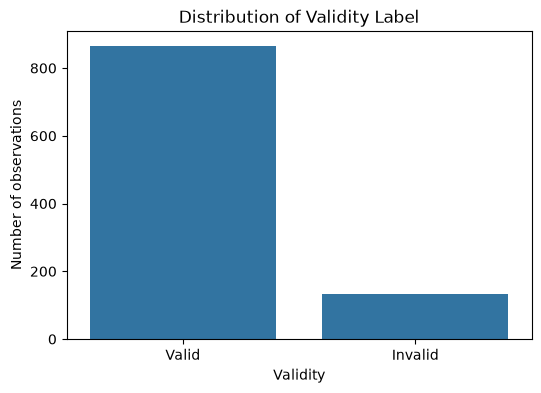

In [16]:
# Taget Forensics - Classification

train["Validity_Label"].value_counts()

class_distribution = (
    train["Validity_Label"]
    .value_counts(normalize=True)
    .mul(100)
)

print(class_distribution) # Imblance

# This directly affects our cross-validation and evaluation strategy

plt.figure(figsize=(6, 4))

sns.countplot(
    data=train,
    x="Validity_Label"
)

plt.title("Distribution of Validity Label")
plt.xlabel("Validity")
plt.ylabel("Number of observations")
plt.show()

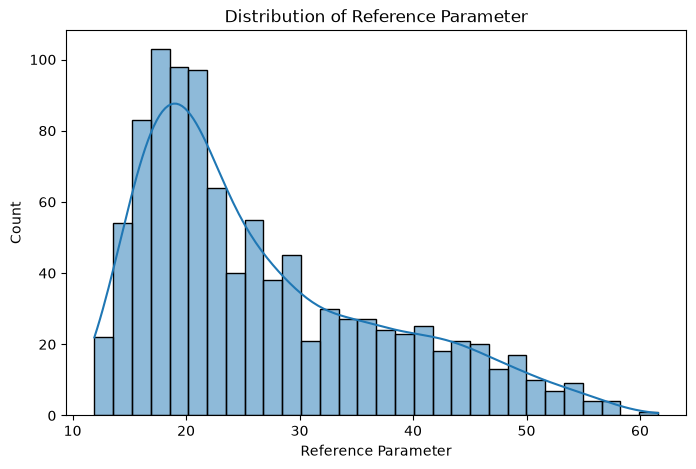

In [17]:
# Target forensics - Regression

train["Reference_Parameter"].describe()

plt.figure(figsize=(8, 5))

sns.histplot(
    data=train,
    x="Reference_Parameter",
    bins=30,
    kde=True
)

plt.title("Distribution of Reference Parameter")
plt.xlabel("Reference Parameter")
plt.show()

**Numerical Feature Distribution**

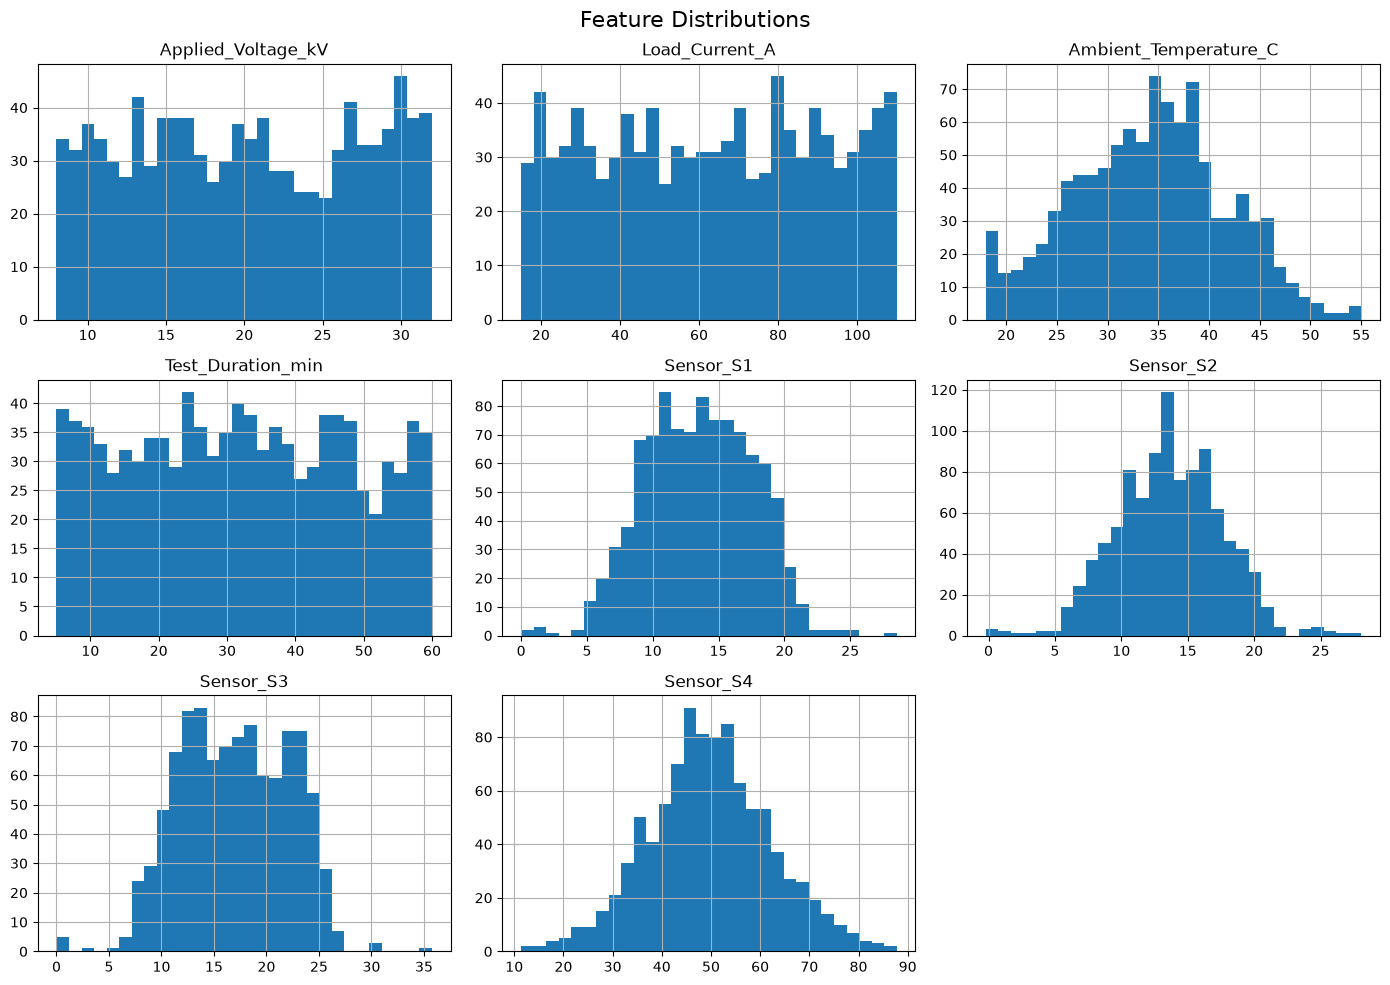

In [18]:
train[feature_cols].hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

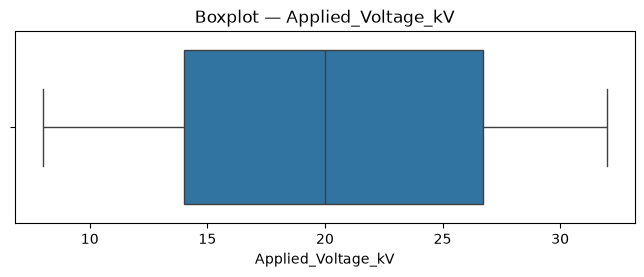

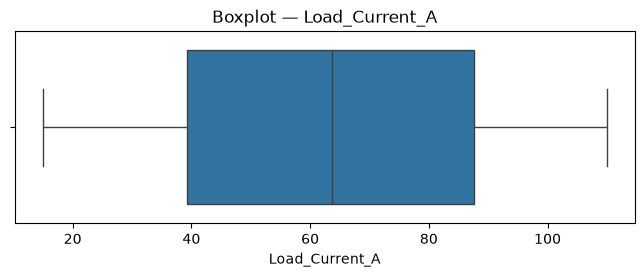

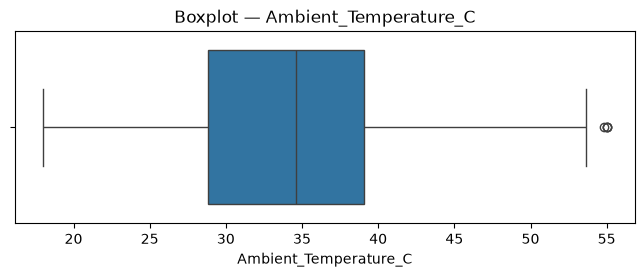

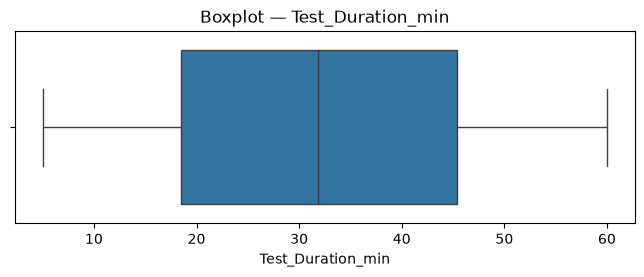

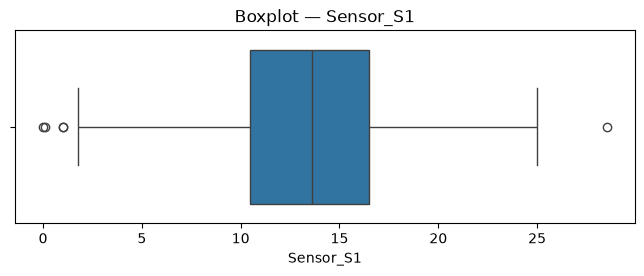

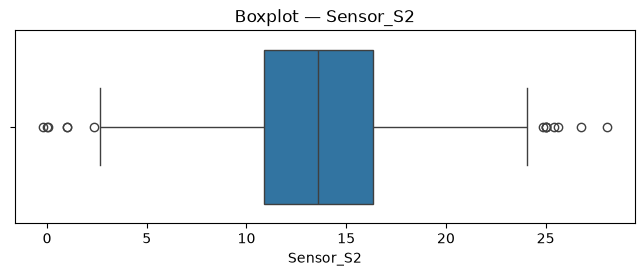

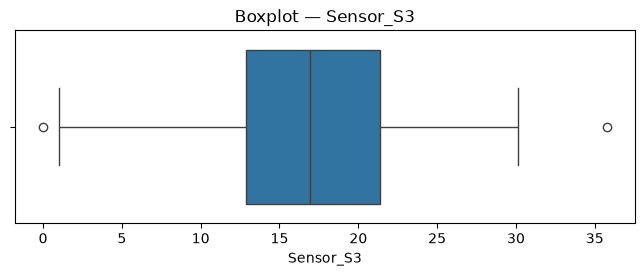

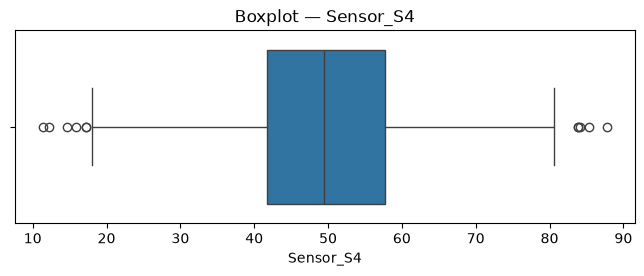

In [19]:
# Boxplots for each feature (For suspicious values) 
for col in feature_cols:

    plt.figure(figsize=(8, 2.5))

    sns.boxplot(
        data=train,
        x=col
    )

    plt.title(f"Boxplot — {col}")
    plt.show()

    # Boxplot point ≠ automatically bad data. (Need not to be)

**Unique values**

In [20]:
for col in feature_cols:
    print(
        f"{col:25s} | Unique values: {train[col].nunique()}"
    )

Applied_Voltage_kV        | Unique values: 988
Load_Current_A            | Unique values: 988
Ambient_Temperature_C     | Unique values: 967
Test_Duration_min         | Unique values: 985
Sensor_S1                 | Unique values: 975
Sensor_S2                 | Unique values: 982
Sensor_S3                 | Unique values: 974
Sensor_S4                 | Unique values: 958


**Correlation Analysis**

*Feature ↔ regression target*

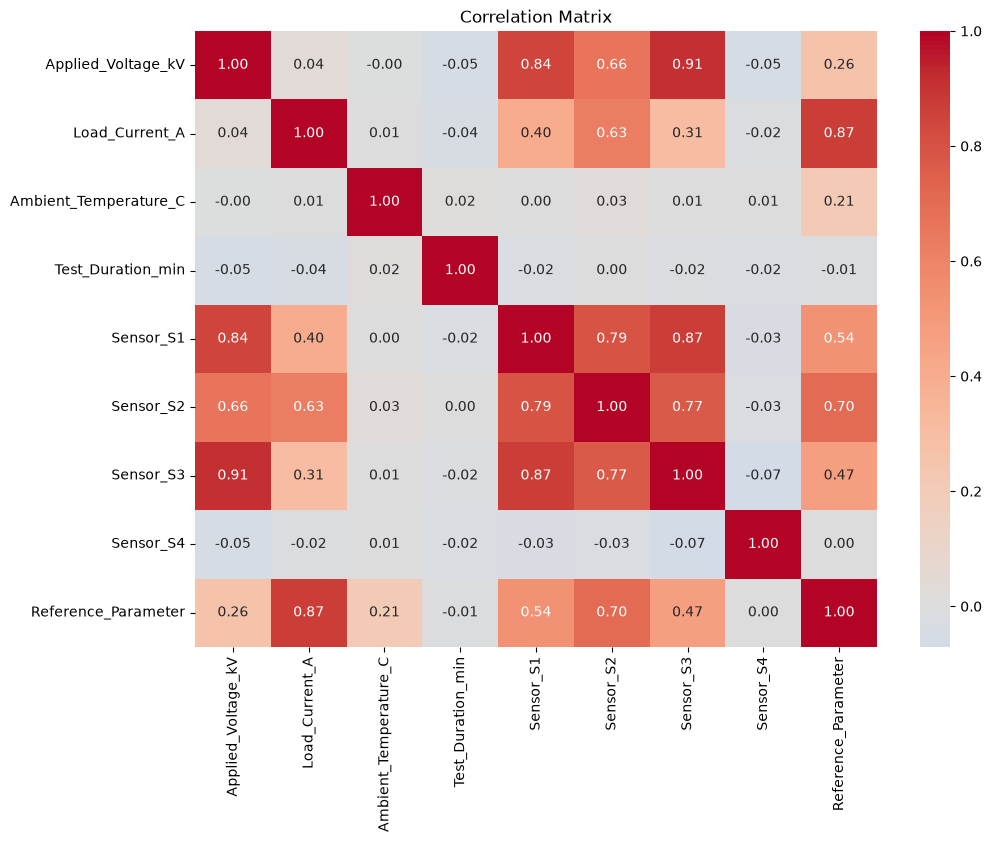

In [21]:
numeric_cols = train.select_dtypes(include=np.number).columns

corr = train[numeric_cols].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

In [22]:
# Ranking Correlation with Reference_Parameter
reference_corr = (
    corr["Reference_Parameter"]
    .drop("Reference_Parameter")
    .sort_values(key=abs, ascending=False)
)

display(reference_corr)

# low correlation ≠ useless feature (Nonlinear models can learn relationship correlation )

Load_Current_A           0.866449
Sensor_S2                0.704494
Sensor_S1                0.535094
Sensor_S3                0.474622
Applied_Voltage_kV       0.263088
Ambient_Temperature_C    0.206248
Test_Duration_min       -0.011523
Sensor_S4                0.002112
Name: Reference_Parameter, dtype: float64

***Hypothesis (From Linear regression)***: 
1) *Reference Parameter is strongly governed by electrical loading, particularly load current.*

2) *S2 may be located at/near a point strongly representative of the hidden reference parameter. (S2 > S1 > S3)*

3) *S4 is essentially zero linear correlation. But it may have nonlinear relationship.*

4) *Thermal systems often have nonlinear/time-dependent behaviour.*



*Feature ↔ validity relationship*

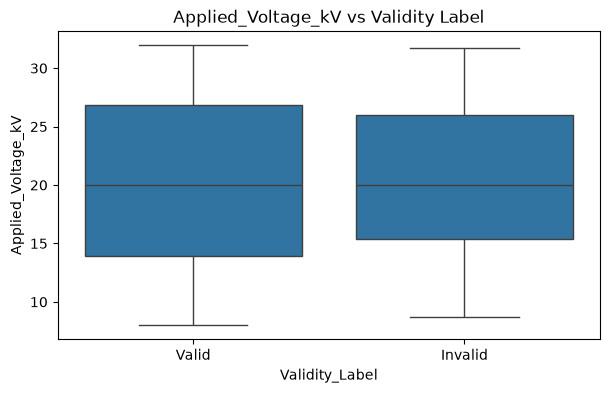

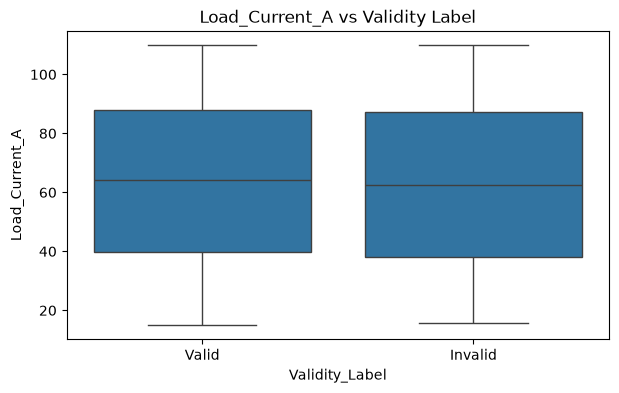

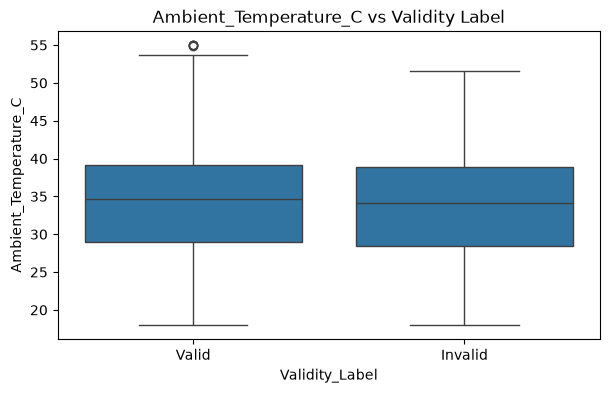

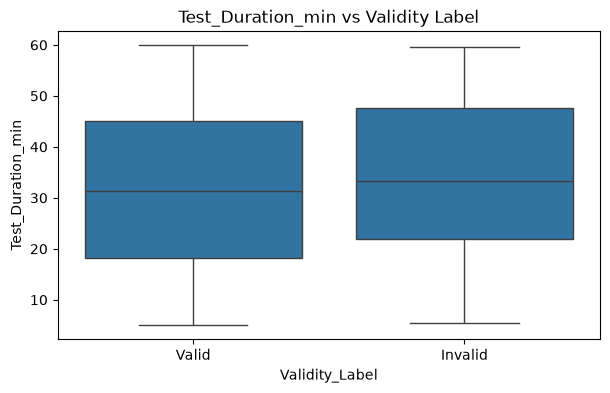

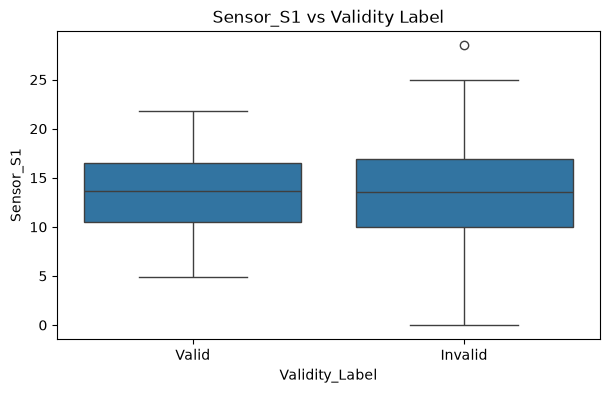

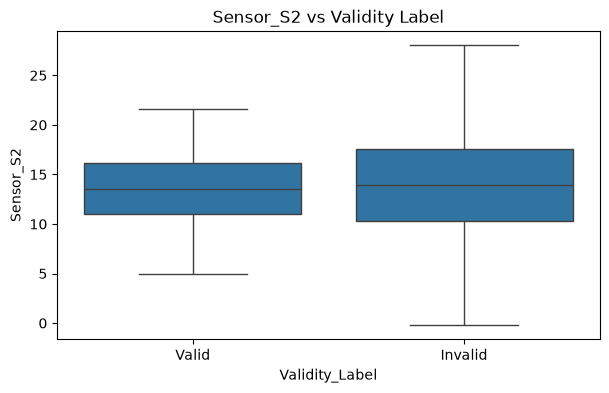

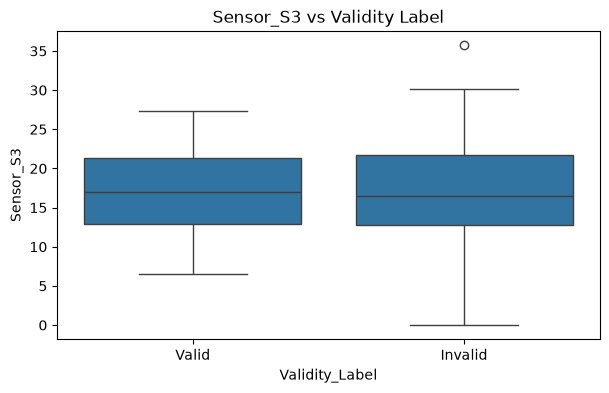

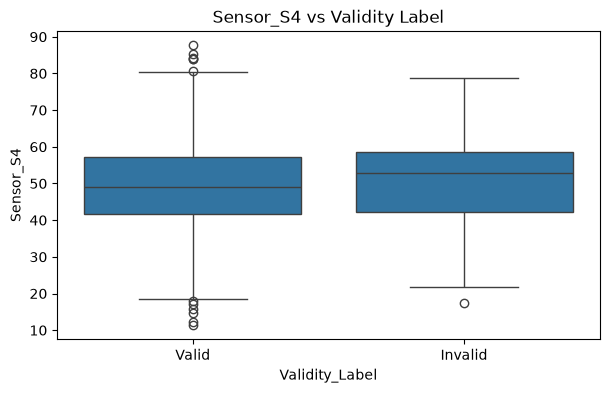

In [23]:
for col in feature_cols:

    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=train,
        x="Validity_Label",
        y=col
    )

    plt.title(f"{col} vs Validity Label")
    plt.show()

*Separated the training data into valid and invalid subsets and recalculated the correlations between the features and the reference parameter.*

<div style="display: flex; gap: 30px; align-items: flex-start;">

<div>

### Valid Rows

| Feature | Correlation |
|---|---:|
| Current | **0.877** |
| S2 | **0.795** |
| S1 | **0.591** |
| S3 | **0.501** |
| Voltage | 0.267 |
| Ambient | 0.238 |
| Duration | ~0 |
| S4 | ~0 |

</div>

<div>

### Invalid Rows

| Feature | Correlation |
|---|---:|
| Current | **0.802** |
| S2 | 0.442 |
| S3 | 0.353 |
| S1 | 0.295 |
| Voltage | 0.240 |
| S4 | 0.077 |
| Ambient | ~0 |
| Duration | -0.054 |

</div>

</div>



The invalid observations appear to have weaker physical relationships between the sensors and the Reference.

**Missingness vs Validity**

In [24]:
for col in ["Sensor_S1", "Sensor_S2", "Sensor_S3", "Sensor_S4"]:

    temp = pd.crosstab(
        train[col].isna(),
        train["Validity_Label"],
        normalize="index"
    )

    print(f"\nMissingness relationship: {col}")
    display(temp)


Missingness relationship: Sensor_S1


Validity_Label,Invalid,Valid
Sensor_S1,,
False,0.128773,0.871227
True,1.000000,0.000000



Missingness relationship: Sensor_S2


Validity_Label,Invalid,Valid
Sensor_S2,,
False,0.132265,0.867735
True,1.000000,0.000000



Missingness relationship: Sensor_S3


Validity_Label,Invalid,Valid
Sensor_S3,,
False,0.127895,0.872105
True,1.000000,0.000000



Missingness relationship: Sensor_S4


Validity_Label,Invalid,Valid
Sensor_S4,,
False,0.138002,0.861998
True,0.000000,1.000000


***SUMMARY***

In [25]:
forensic_summary = pd.DataFrame({
    "Feature": train.columns,
    "Data_Type": train.dtypes.astype(str).values,
    "Missing": train.isna().sum().values,
    "Missing_%": (train.isna().mean().values * 100).round(2),
    "Unique": train.nunique().values
})

display(forensic_summary)

,Feature,Data_Type,Missing,Missing_%,Unique
0,Test_ID,str,0,0.0,1000
1,Applied_Voltage_kV,float64,0,0.0,988
2,Load_Current_A,float64,0,0.0,988
3,Ambient_Temperature_C,float64,0,0.0,967
4,Test_Duration_min,float64,0,0.0,985
5,Sensor_S1,float64,6,0.6,975
6,Sensor_S2,float64,2,0.2,982
7,Sensor_S3,float64,7,0.7,974
8,Sensor_S4,float64,29,2.9,958
9,Reference_Parameter,float64,0,0.0,999


***The Validity_Label identifies whether the complete test measurement is trustworthy, and Invalid records may contain corrupted/inconsistent reference values and/or sensor measurements.***